# Import Required Libraries
Import the necessary libraries, including the dataset loader from src/dataloaders/datasets/a_thaliana_dataset.py.

In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from datasets import Dataset

# list of HyenaDNA pretrained models available in the hugging face hub
pretrained_models_max_length = {
    'hyenadna-tiny-1k-seqlen-hf': 1024,
        'hyenadna-small-32k-seqlen-hf': 32768,
        'hyenadna-medium-160k-seqlen-hf': 160000,
        'hyenadna-medium-450k-seqlen-hf': 450000,  # T4 up to here
        'hyenadna-large-1m-seqlen-hf': 1_000_000,
}
pretrained_model_name = 'hyenadna-small-32k-seqlen-hf'

# instantiate pretrained model
checkpoint = 'LongSafari/'+pretrained_model_name
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)

/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


# Exploratory Data Analysis (EDA)
Load the dataset using the provided BED and FA files.

In [3]:
# Import the dataset loader
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/A.Thaliana.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = 2000,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )

In [4]:
ds_test.label_dict

{'gene': 0, 'intergenic': 1}

In [5]:
data_test = []
labels_test = []
for _, (d, l) in enumerate(ds_test):
    data_test.append(d.tolist())
    labels_test.append(l.item())

In [6]:
len(data_test), len(labels_test)

(1234, 1234)

In [10]:
seq_0 = str.join('',tokenizer.convert_ids_to_tokens(data_test[0]))
print(seq_0)
print(len(seq_0))

AAAAGCTAACAACATTTGATGGGTCGGAAATAGGCGGCAGAATAACAACTGCCGCCAAAAAAATAAAAAAACGAAAATATATAATTACACATTTACACCAAAGTGTGATCTAAATTGAACGGTGCAGATTAGTTTAACATTTATCCCAAATTTTAAGAACCGTACGATGGAGCATCTTAATGACTTAAACCCTAAAAGAAGAAAAACCCCAATCGAGCTCTGTCAATGGCTCGCTTCGTCAGATGTCTGAGAAGAACACTCTTTTCTAATTCGTCTCCTTCTATTGCTCACCGGAGCCCTAGGATTGGTTTGCCCACGAATCTAAATCCTAAAATTTTAATCAGCCGCAGATGTCTGAGCTCCGGGAGTTACGTCTCAGAAATGCAGAAATCAGCTTTCCAGGGCAACATTTTGCGACTGATCCGTAATGAGATTGAGTACGAACTCGATCACTCGCCTCCTCTTCAGGTTCTCTATGAATCTCTTTTTTTTTGGTTCTATATTCTTTAAGCCTTCTAGGAATCTGGTTTTGGAATAGTGTTATTGATCAATTGATTGTTTTGGCATGAGAATCATATAAATGTTGATCTGTATAGTGTAACTTAGGTTGATACAATTTGTAAACTATTGGATGAAGAAAATGTTCACATCTCTGCAATGGCCTCTCTGTTTTGGGATTTGCAAGTTTTTTTTTTTTTTGGCAAGTTGCAGTGACCTCTTATAAACCCATACGTTAGCTAGTGACAACTTTCTAGTTCGTCTACAATGCATTTCCATGAACTTTTGCTTCCATTTCCGACATTTCTCCCACTGGCTACATTGAATAATACTTTGAGCACTTTTGCTTGTACAAATTTGCAGCCTCCTAACAGTTTTGGTCCATTCACTGTGGATGAACGGCCTGGAGAGCAGTGGATTAGCTTGAAAAGGAATTTTGGGGATAAAGAAGACATCAAAATTGAAGCAACTATGTTTGATAGATCAGTTCCCACGTCAAAAT

### Display Dataset Information
Display basic information about the dataset, such as the number of entries and a preview of the data.

In [11]:
# Display basic information about the dataset
# Number of entries in the dataset
num_entries = len(ds_test)
print(f"Number of entries in the dataset: {num_entries}")

Number of entries in the dataset: 1234


In [18]:
seq_0 = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(data_test[-1]))
print(seq_0)
print(len(seq_0))

GCTTAGAAGAGTCAACCAAAACCCCTGGCCCTTTCTAGAAGGGCCTGACATCAACGTTAACATGGTCTGACCTTACCTGTGGATTTCGATACCCAACATAGCTCCCTAGGCTCCTCAGCAGGGGTCACTGAGGATTAACTGTAAACACGGCGCCTCTATTATGGCCGCGCGATACCCGTACGAGATACTCGTGGGTACCCTTGAGACTTTGTTTAAAGCTGCTTTTTCATTAAGTTAACCAATGATTACAAATAGTTAAACGGATGTAGTTAATGCGGTATAAATAATATTTACTGTTGTAGCTTTGAATGGGTGAGTGGCGTGGCAGGGTTTGGTGCCCAATAAATTAATAAACACGTTTTGTTTCCATTCATCCAAAAAATGGGACCGTATATACAGTGGCATGTTCATTTTGGGTAACGAGCCGGGTAATGCGATAAGGGTCGGAAATATATAAAAAGTACTATCGAAACATACACGATAATTTATGAGATGAAACTTTCAGTTCATATATTGGGTTAGTTAGTTTCTATACGTAAAATCATTACCCTCACTCTTATTTTCAAATTTAGAAAATAAGTACTTGTGGAAATTTAAAAAAGATTCAAATTTACTAAATATGCGAGTAGGATTTTATTTTTTCCTATTGTTAATATATTTTTGCGCTATAATAAACGAAATTGTCCTAATTGTAGATAGTAAATTTAGCAAAGACCATTGCAGCAATGTGTGCAACCTTATGTAGAACTATTTAGTGATGCGGTAAGAAGATGACAATAAAAAGAGGTGTCAATAGTTGGTGGTACAAAACACAAACACTAGTGACAGAAAGAGTATTGTACTGCCATCATTTTGAAATTTCAATATTAATTTTTCTAATTAAACTCTTTCAAGTGAAACTAATAACCATGTGTTGCATGAAAATTCTTTTCAACGTCCGTTTTCGTTTCTAAAACGCAGGTATAAACTATTTTTTTTCCTTTATCCTTTAATTAAACTA

In [147]:
from Bio import SeqIO
from Bio.Seq import Seq

def find_sequence_in_fasta(fasta_file, query_sequence):
    seq_len = len(query_sequence)
    # Cargar el archivo FASTA
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequence = str(record.seq)
        sequence = sequence.upper() # Convertir a mayúsculas
        reverse_complement_seq = str(record.seq.reverse_complement())
        chr_len = len(sequence)

        # Buscar la secuencia directa
        if query_sequence in sequence:
            start = sequence.find(query_sequence)
            end = start + seq_len
            print(f"Secuencia encontrada en {record.id} (strand +) en la posición: {start}")
            print(f"{record.id}, seq in strand +: {sequence[start: end]}")
            return (record.id, start, end, '+')

        # Buscar el reverse complement
        if query_sequence in reverse_complement_seq:
            end = chr_len - reverse_complement_seq.find(query_sequence)
            start = end - seq_len
            print(f"Secuencia encontrada en {record.id} (strand -) en la posición: {start} del strand +")
            print(f"{record.id}, seq in strand +: {reverse_complement_seq[start: end]}")
            return (record.id, start, end, '-')

    print("Secuencia no encontrada en el archivo FASTA.")
    return None

In [19]:
# Buscar la secuencia
result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_0)
if result:
    chr, start, end, strand = result
    print(f"Coordenadas: chr={chr}, start={start}, end={end}, strand={strand}")

Secuencia no encontrada en el archivo FASTA.


In [44]:
import pandas as pd

# carga el archivo A_Thaliana.bed en un dataframe
df = pd.read_csv(bed_file_path, sep='\t', header=None)
df.columns = ['chr', 'start', 'end', 'label', 'split', 'strand']
df.head()

,chr,start,end,label,split,strand
0,chr1,50000,50100,gene,2,-
1,chr2,519826,525528,intergenic,0,.
2,chr1,756262,757300,intergenic,2,-
3,chr4,759357,768230,intergenic,2,.
4,chr5,723043,723288,gene,1,+


In [ ]:
from BCBio import GFF

def gff_to_bed(gff_file, bed_file):
    with open(gff_file) as gff_handle, open(bed_file, 'w') as bed_handle:
        for rec in GFF.parse(gff_handle):
            for feature in rec.features:
                if feature.type == "gene":
                    chrom = rec.id
                    start = feature.location.start
                    end = feature.location.end
                    name = feature.qualifiers.get("Name", [""])[0]
                    score = 0
                    strand = feature.strand
                    bed_handle.write(f"{chrom}\t{start}\t{end}\t{name}\t{score}\t{strand}\n")

# Uso de la función
gff_file = "path/to/your_file.gff"
bed_file = "path/to/your_file.bed"
gff_to_bed(gff_file, bed_file)

## Train HyenaDNA with gene-intergen dataset

In [149]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# instantiate pretrained model
pretrained_model_name = 'hyenadna-small-32k-seqlen-hf'
checkpoint = 'LongSafari/'+pretrained_model_name
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)
model  = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/special_tokens_map.json
loading file tokenizer_config.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/tokenizer_config.json
loading configuration file config.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/config.json
Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
loading c

### Data loading

In [2]:
# Experiment settings:

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/A.Thaliana.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'
# Other dataset settings
use_padding = True
rc_aug = True  # reverse complement augmentation
add_eos = False  # add end of sentence token
# Training settings
num_epochs = 5  # ~5 seems fine
max_length = 2000  # max len of sequence of dataset (of what you want)
batch_size = 64 # ~256 was used
learning_rate = 8e-5  # 6e-4 good default for Hyena
weight_decay = 0.1

In [3]:
# Import the dataset loader
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )
ds_val = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='val', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )
ds_train = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='train', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )

print(f"Train dataset shape:[{len(ds_train)},{len(ds_train[0]['input_ids'])}]")
print(f"Train labels shape:[{len(ds_train)},{len(ds_train[0]['labels'])}]")  
print(f"Evaluation dataset shape:[{len(ds_val)},{len(ds_val[0]['input_ids'])}]")
print(f"Evaluation labels shape:[{len(ds_val)},{len(ds_val[0]['labels'])}]")
print(f"Test dataset shape:[{len(ds_test)},{len(ds_test[0]['input_ids'])}]")
print(f"Test labels shape:[{len(ds_test)},{len(ds_test[0]['labels'])}]")

Train dataset shape:[9603,2000]
Train labels shape:[9603,1]
Evaluation dataset shape:[1163,2000]
Evaluation labels shape:[1163,1]
Test dataset shape:[1234,2000]
Test labels shape:[1234,1]


In [12]:
ds_test[0].keys()

dict_keys(['input_ids', 'labels'])

In [ ]:
# Not used any more
# Dataset.from_dict expects input_ids as a nested list with size [batch, seq_len] 
# and labels as a list with size [batch]
data_train = []
labels_train = []
for _, (d, l) in enumerate(ds_train):
    data_train.append(d.tolist())
    labels_train.append(l.item())

DS_train = Dataset.from_dict({"input_ids": data_train, "labels": labels_train})
DS_train.set_format('pt')
# shuffle the dataset
DS_train = DS_train.shuffle(seed=42)

data_val = []
labels_val = []
for _, (d, l) in enumerate(ds_val):
    data_val.append(d.tolist())
    labels_val.append(l.item())

DS_val = Dataset.from_dict({"input_ids": data_val, "labels": labels_val})
DS_val.set_format('pt')
# shuffle the dataset
DS_val = DS_val.shuffle(seed=42)

data_test = []
labels_test = []
for _, (d, l) in enumerate(ds_test):
    data_test.append(d.tolist())
    labels_test.append(l.item())

DS_test = Dataset.from_dict({"input_ids": data_test, "labels": labels_test})
DS_test.set_format('pt')
# shuffle the dataset
DS_test = DS_test.shuffle(seed=42)


print(f"Train dataset shape:[{len(DS_train.data)},{len(DS_train.data['input_ids'][0])}]")
print(f"Train labels shape:[{len(DS_train.data['labels'])}]")  

print(f"Validation dataset shape:[{len(DS_val.data)},{len(DS_val.data['input_ids'][0])}]")
print(f"Validation labels shape:[{len(DS_val.data['labels'])}]")

print(f"Test dataset shape:[{len(DS_test.data)},{len(DS_test.data['input_ids'][0])}]")
print(f"Test labels shape:[{len(DS_test.data['labels'])}]")  

### Trianing

In [4]:
# filter out warnings
import warnings
warnings.filterwarnings("ignore")

# disable wandb
import os 
os.environ["WANDB_DISABLED"] = "true"

In [150]:
from torch.utils.data import Subset

train_len = min(64*46,len(ds_train))
val_len = min(100,len(ds_val))

subset_train = Subset(ds_train, torch.randperm(len(ds_train)).tolist()) # shuffle the dataset
subset_train = Subset(subset_train, range(train_len)) # take a subset of the dataset

subset_val = Subset(ds_val, torch.randperm(len(ds_val)).tolist()) # shuffle the dataset
subset_val = Subset(subset_val, range(val_len)) # take a subset of the dataset

In [151]:
from transformers import TrainerCallback, TrainingArguments, Trainer

# Define el callback for logging the loss
class LossLoggerCallback(TrainerCallback):
    def __init__(self):
        self.train_loss = []
        self.eval_loss = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if 'loss' in logs:
                self.train_loss.append(logs['loss'])
            if 'eval_loss' in logs:
                self.eval_loss.append(logs['eval_loss'])

# Define el callback
loss_logger = LossLoggerCallback()

# Define los argumentos de entrenamiento
args = {
    "output_dir": "tmp",
    "num_train_epochs": num_epochs,
    "per_device_train_batch_size": batch_size,
    "per_device_eval_batch_size": batch_size,
    "evaluation_strategy": "epoch", # eval after each epoch
    "gradient_accumulation_steps": 4, # for larger batch sizes
    #"gradient_checkpointing": True, # 'HyenaDNAForSequenceClassification' object has no attribute '_set_gradient_checkpointing'
    "learning_rate": learning_rate,
    "logging_strategy": "epoch",
    "save_strategy": "epoch",
}
training_args = TrainingArguments(**args)

# Crea el Trainer y añade el callback
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=subset_train,
    eval_dataset=subset_val,  # Asegúrate de incluir el dataset de evaluación
    callbacks=[loss_logger]
)


PyTorch: setting up devices
The default value for the training argument `--report_to` will change in v5 (from all installed integrations to none). In v5, you will need to use `--report_to all` to get the same behavior as now. You should start updating your code and make this info disappear :-).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [152]:
# Entrena el modelo
result = trainer.train()

***** Running training *****
  Num examples = 2944
  Num Epochs = 5
  Instantaneous batch size per device = 64
  Total train batch size (w. parallel, distributed & accumulation) = 256
  Gradient Accumulation steps = 4
  Total optimization steps = 55
  Number of trainable parameters = 3278080
 20%|██        | 11/55 [00:47<03:00,  4.10s/it]***** Running Evaluation *****
  Num examples = 100
  Batch size = 64


{'loss': 0.5552, 'learning_rate': 6.400000000000001e-05, 'epoch': 0.96}



 20%|██        | 11/55 [00:48<03:00,  4.10s/it]Saving model checkpoint to tmp/checkpoint-11
Configuration saved in tmp/checkpoint-11/config.json
Model weights saved in tmp/checkpoint-11/pytorch_model.bin


{'eval_loss': 0.2517968714237213, 'eval_runtime': 0.66, 'eval_samples_per_second': 151.526, 'eval_steps_per_second': 3.031, 'epoch': 0.96}


 40%|████      | 22/55 [01:36<02:17,  4.15s/it]***** Running Evaluation *****
  Num examples = 100
  Batch size = 64


...

{'loss': 0.1547, 'learning_rate': 0.0, 'epoch': 4.96}



100%|██████████| 55/55 [04:00<00:00,  4.14s/it]Saving model checkpoint to tmp/checkpoint-55
Configuration saved in tmp/checkpoint-55/config.json
Model weights saved in tmp/checkpoint-55/pytorch_model.bin


{'eval_loss': 0.13890625536441803, 'eval_runtime': 0.5936, 'eval_samples_per_second': 168.465, 'eval_steps_per_second': 3.369, 'epoch': 4.96}




Training completed. Do not forget to share your model on huggingface.co/models =)


100%|██████████| 55/55 [04:00<00:00,  4.38s/it]

{'train_runtime': 240.9509, 'train_samples_per_second': 61.091, 'train_steps_per_second': 0.228, 'train_loss': 0.25795787464488634, 'epoch': 4.96}


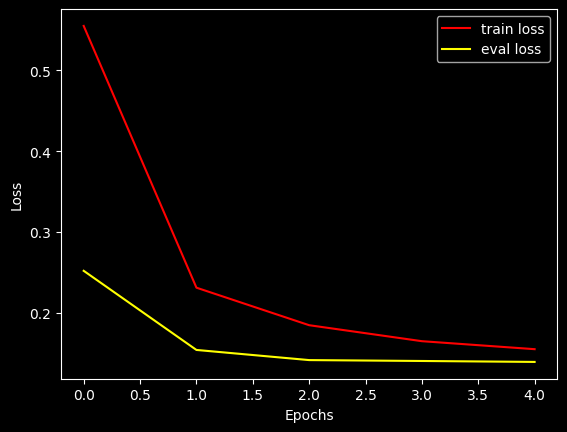

In [153]:
# Plot the loss
import matplotlib.pyplot as plt

plt.plot(loss_logger.train_loss, label="train loss", color='red')
plt.plot(loss_logger.eval_loss, label="eval loss", color='yellow')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

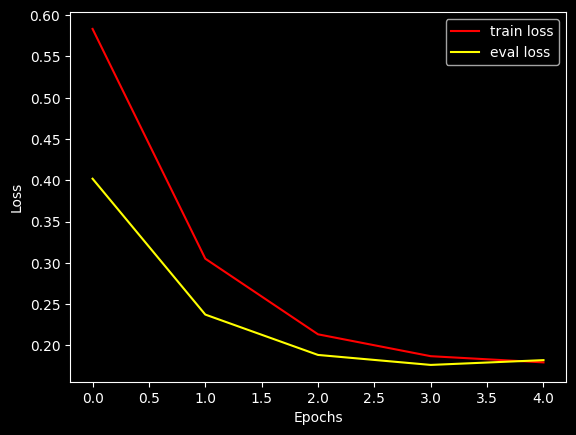

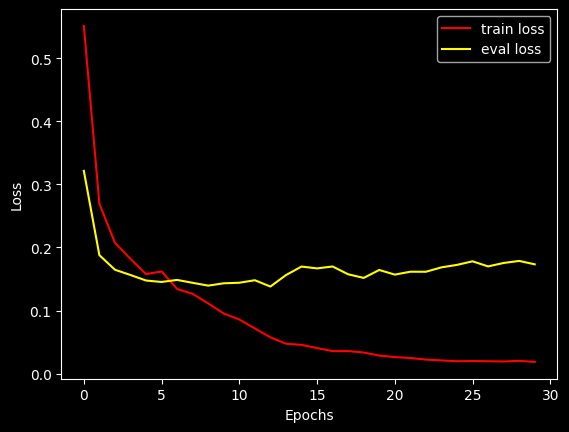

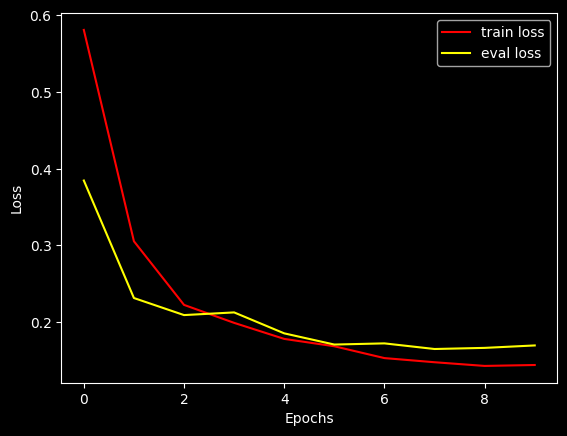

### Saving the trained model

In [10]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Supongamos que `model` es tu modelo entrenado y `tokenizer` es tu tokenizador
model_dir = "saved_model"

# Guardar el modelo
model.save_pretrained(model_dir)
print(f"Modelo guardado en {model_dir}")

# Guardar el tokenizador (opcional, si tienes un tokenizador)
tokenizer.save_pretrained(model_dir)
print(f"Tokenizador guardado en {model_dir}")

Configuration saved in saved_model/config.json
Model weights saved in saved_model/pytorch_model.bin
tokenizer config file saved in saved_model/tokenizer_config.json
Special tokens file saved in saved_model/special_tokens_map.json


Modelo guardado en saved_model
Tokenizador guardado en saved_model


# Model Evaluation

In [154]:
print(f"eval loss: {loss_logger.eval_loss[-1]}")
print(f"data length: {len(subset_train)}")

eval loss: 0.13890625536441803
data length: 2944


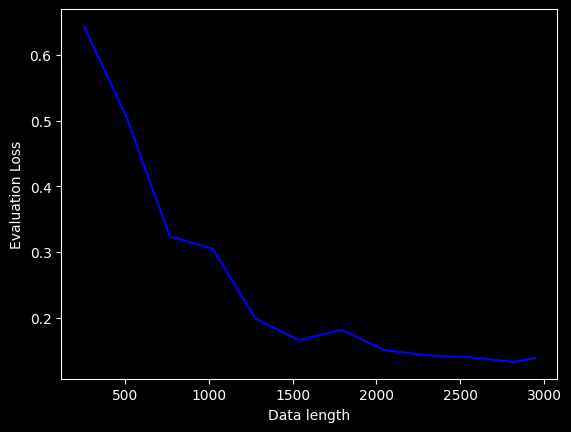

In [156]:
data_len = [256, 512, 768, 1024, 1280, 1536, 1792, 2048, 2304, 2560, 2816, 2944]
eval_loss = [0.644,0.504, 0.324, 0.305, 0.199, 0.166, 0.182, 0.151, 0.143, 0.140, 0.133, 0.139]

plt.plot(data_len, eval_loss, label="eval loss", color='blue')
plt.xlabel("Data length")
plt.ylabel("Evaluation Loss")
plt.show()

### Loading the trained model

In [5]:
# reload fine-tuned model
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model_dir = "saved_model"

# Crear una nueva instancia del modelo y cargar los pesos guardados
model = AutoModelForSequenceClassification.from_pretrained(model_dir, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)
print(f"Modelo cargado desde {model_dir}")

# Cargar el tokenizador (opcional, si tienes un tokenizador)
tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
print(f"Tokenizador cargado desde {model_dir}")

Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


Modelo cargado desde saved_model
Tokenizador cargado desde saved_model


### Dummy experiment
Not trained model evaluation

In [35]:
model_non_trained_head  = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

loading configuration file config.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/config.json
Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
loading configuration file config.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/config.json
Model config HyenaConfig {
  "_name_or_path": "LongSafari/hyenadna-small-32k-seqlen-hf",
  "activation_freq": 10,
  "architectures": [
    "HyenaDNAForCausalLM"
  ],
  "auto_map": {
    "AutoConfig": "configuration_hyena.HyenaConfig",
    "AutoModel": "modeling_hyena.HyenaDNAModel",
    "AutoModelForCausalLM": "modeling_hyena.HyenaDNAForCausalLM",
    "AutoModelForSequenceClassification": "modeling_hyena.HyenaDNAForSequenceClass

In [38]:
import numpy as np
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Get a sample of test data
np.random.seed(42)
idx = np.random.randint(0, len(subset_train), 100)

data = torch.stack([subset_train[i]["input_ids"] for i in idx])
target = torch.stack([subset_train[i]["labels"] for i in idx])
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model_non_trained_head.eval()
with torch.no_grad():
    output = model_non_trained_head(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Usando dispositivo: cuda
Loss: 0.8633, Accuracy: 46.00%


The evaluation of the non-trained model shows the expected accuracy of 50% 

### Evaluate the model on trainig data

In [58]:
import numpy as np
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Get a sample of test data
np.random.seed(42)
idx = np.random.randint(0, len(subset_train), 100)

data = torch.stack([subset_train[i]["input_ids"] for i in idx])
target = torch.stack([subset_train[i]["labels"] for i in idx])
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Usando dispositivo: cuda
Loss: 0.0120, Accuracy: 100.00%


This is an overfitting experiment:

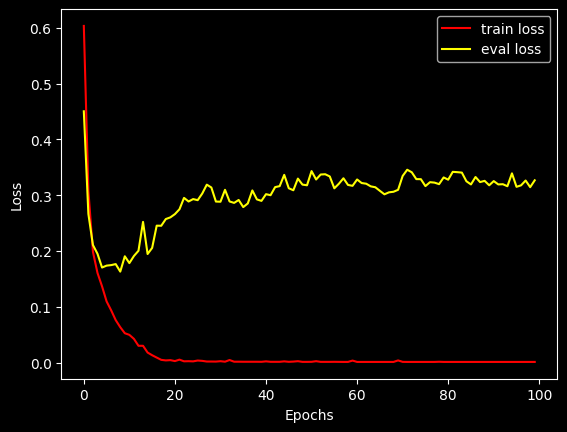

Accuracy 100% on tranig data.

In [14]:
print(training_args)

TrainingArguments(
_n_gpu=1,
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_pin_memory=True,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_steps=None,
evaluation_strategy=epoch,
fp16=False,
fp16_backend=auto,
fp16_full_eval=False,
fp16_opt_level=O1,
fsdp=[],
fsdp_min_num_params=0,
fsdp_transformer_layer_cls_to_wrap=None,
full_determinism=False,
gradient_accumulation_steps=4,
gradient_checkpointing=False,
greater_is_better=None,
group_by_length=False,
half_precision_backend=auto,
hub_model_id=None,
hub_private_repo=False,
hub_strategy=every_save,
hub_token=<HUB_TOKEN>,
ignore_data_skip=False,
include_inputs_for_metrics=False,
jit_mode_eval=False,
label_n

In [22]:
# Load the model from a specific epoch checkpoint
step_number = 26000  # Specify the epoch number you want to load
checkpoint_path = f"tmp/checkpoint-{step_number}"
model_saved = AutoModelForSequenceClassification.from_pretrained(checkpoint_path, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

loading configuration file tmp/checkpoint-26000/config.json
Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
loading configuration file tmp/checkpoint-26000/config.json
Model config HyenaConfig {
  "_name_or_path": "tmp/checkpoint-26000",
  "activation_freq": 10,
  "architectures": [
    "HyenaDNAForSequenceClassification"
  ],
  "auto_map": {
    "AutoConfig": "configuration_hyena.HyenaConfig",
    "AutoModel": "modeling_hyena.HyenaDNAModel",
    "AutoModelForCausalLM": "modeling_hyena.HyenaDNAForCausalLM",
    "AutoModelForSequenceClassification": "modeling_hyena.HyenaDNAForSequenceClassification"
  },
  "d_inner": 512,
  "d_model": 128,
  "emb_dim": 5,
  "embed_dropout": 0.1,
  "filter_order": 64,
  "hyena_dropout": 0.0,
  "hyena_filter_dropout": 0.0,
  "hyena_order": 2,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "max_seq_len": 1026,
  "model_type": "hy

### Evaluate the model on validation data

In [157]:
import numpy as np
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Get a sample of test data
np.random.seed(42)
idx = np.random.randint(0, len(subset_val), 100)

data = torch.stack([subset_val[i]["input_ids"] for i in idx])
target = torch.stack([subset_val[i]["labels"] for i in idx])
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Usando dispositivo: cuda
Loss: 0.1934, Accuracy: 95.00%


In [37]:
ds_val.label_dict

{'gene': 0, 'intergenic': 1}

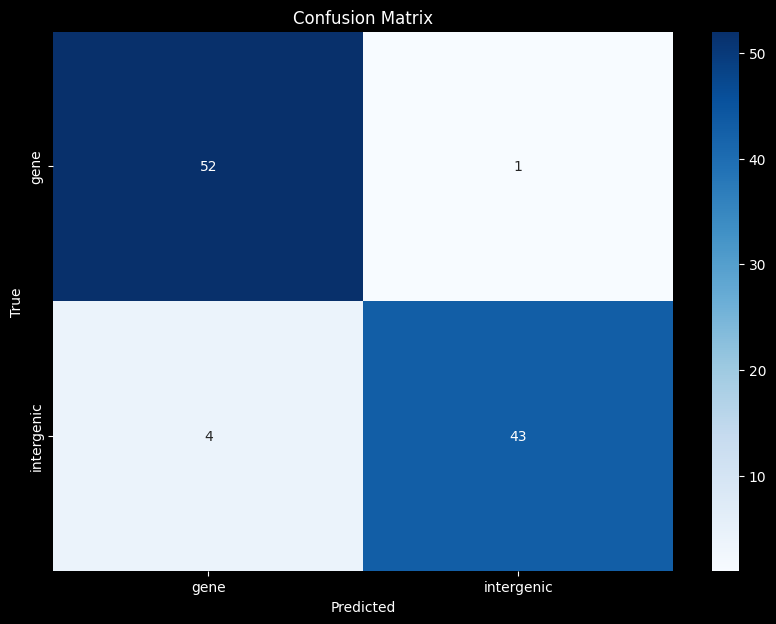

In [158]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Convert tensors to numpy arrays
pred_np = pred.cpu().numpy()
target_np = target.cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(target_np, pred_np)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['gene', 'intergenic'], yticklabels=['gene', 'intergenic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [159]:
# Identificar falsos positivos y falsos negativos
pred = pred.squeeze().to('cpu')
target = target.squeeze().to('cpu')

positive_class = ds_val.label_dict['gene']
negative_class = ds_val.label_dict['intergenic']

FP = (pred != negative_class) & (target == negative_class)
FN = (pred != positive_class) & (target == positive_class)

# Extraer ejemplos de falsos positivos y falsos negativos
data = torch.stack([subset_val[i]["input_ids"] for i in idx]).to('cpu')

ejemplos_fp = data[FP]
ejemplos_fn = data[FN]

print(f'Falsos positivos: {ejemplos_fp.shape[0]}')
print(f'Falsos negativos: {ejemplos_fn.shape[0]}')

# Opcional: Imprimir algunos ejemplos
print("Ejemplos de falsos positivos:", ejemplos_fp[:5])
print("Ejemplos de falsos negativos:", ejemplos_fn[:5])

Falsos positivos: 4
Falsos negativos: 1
Ejemplos de falsos positivos: tensor([[ 8,  9, 10,  ..., 10, 10,  9],
        [ 7,  9,  8,  ...,  9,  9,  8],
        [ 8, 10, 10,  ..., 10, 10,  9],
        [ 8,  9, 10,  ..., 10, 10,  9]])
Ejemplos de falsos negativos: tensor([[10, 10, 10,  ...,  7,  8, 10]])


In [160]:
from torch.nn import functional as F

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(ejemplos_fn.to(device))

# Get the predicted class
probabilidades = F.softmax(output["logits"], dim=-1)

print("Probabilidades:", probabilidades)

Probabilidades: tensor([[0.1514, 0.8477]], device='cuda:0', dtype=torch.bfloat16)


In [148]:
seq_fn = str.join('',tokenizer.convert_ids_to_tokens(ejemplos_fn[0]))
# Buscar la secuencia
result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_fn)
if result:
    chr, start, end, strand = result
    print(f"Coordenadas: chr={chr}, start={start}, end={end}, strand={strand}")

Secuencia encontrada en Chr2 (strand +) en la posición: 5166984
Chr2, seq in strand +: TTTTTCTTATGAATTTATAAGGTATGCTAAACTAATATCTACGTAAGCAAAATAAAATAAAATAAAAAACTGATTATAAACTTTATTAGAGAGACCGCACGACAAGAATCCATACATGTAACATATAAGACTATATGGTGAAAAGAAACTAATAAAGAAGATTAGAAAACAAAAACAAAGAAGAAAAGAGTACGTTAACAGAGAGGAGATCGTTGAGGAACGCCTTTTCGCCGATTGATGCAAGCAGAAATATCGTCAGGATCCTCCGAAACTTCTTTATAACTATTAGCCGATTTAGCGCAAAGGCAAAAACCAGTCCTTTTTTTCCTCACGACATGGGTGGTGGTTGCGGCATAAGCAGCCGCCGCACCCGCATTGTTGTTATCCGAGGAAGCTGAGGACCAGCTCATGGACTCATCGCCGTCTACCACAGTTGATCGAGGAGTCTCGTAGGCCGCCACTTCATCATCTGTCAGTAAGTCTTGTGGGATGATGTAGTCAGGACCTAGGGTTAGAGTGTGGCATGGCTTGAGGAATGGGGTTATGTCCCTGTAACGTTTCATCACAAAGTCCACCTACATGTATATAAACCAAAACCTTTTATATAATCACATAGATTACTACATGCTCAAAAAGCTTAGATGTTATTCTGAGAACATGATATATTTATTACAAAGTGCAACATTGAAAAGATTTGAAAGTGTGGTGGTTTCTTAAAACACTTAGGGCCAAACCACTAGCTCAAATGATATGGGAGTATTTACAGTATTTATGCACCAAATTTACATAGTTCCAAGTTCCAATGGCAAGGTCAATGATAGACTTATTTATTAAAAAAGTTAGCCTCCCCTTTATAGAATTTCTTCATGTTTTTTTTTTTGTTAAATACATTAGTTCAGAAGGACAAGATTTC